In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# read in all of the words
words = open('names.txt', 'r').read().splitlines()
words[0:]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [4]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [53]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

    
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [54]:
X.shape, X.dtype, Y.shape, Y.dtype 

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [256]:
# build the dataset

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
    
        
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182778, 3]) torch.Size([182778])
torch.Size([22633, 3]) torch.Size([22633])
torch.Size([22735, 3]) torch.Size([22735])


In [140]:
C = torch.randn((27, 2))

In [141]:
C[5]

tensor([ 1.2890, -0.8789])

In [142]:
C[X]

tensor([[[-1.0175,  1.2499],
         [-1.0175,  1.2499],
         [-1.0175,  1.2499]],

        [[-1.0175,  1.2499],
         [-1.0175,  1.2499],
         [ 1.2890, -0.8789]],

        [[-1.0175,  1.2499],
         [ 1.2890, -0.8789],
         [ 1.5775, -0.5121]],

        ...,

        [[ 0.4252,  1.6577],
         [ 0.4252,  1.6577],
         [ 0.7241, -0.4271]],

        [[ 0.4252,  1.6577],
         [ 0.7241, -0.4271],
         [ 0.4252,  1.6577]],

        [[ 0.7241, -0.4271],
         [ 0.4252,  1.6577],
         [ 0.0387, -0.0787]]])

In [143]:
C[X].shape # for all 32 examples give out 2 dimensional embeddings for the 3 chars present in each example

torch.Size([228146, 3, 2])

In [144]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [145]:
w1 = torch.randn((6, 100)) # 6 as per block we have 3 chars each with 2 dimensional embeddings so 3x2 = 6, 100 represents the number of neurons we are taking can be changed as per wish
b1 = torch.randn(100)

In [146]:
#emb @ w1 + b1, cannot do this operation as emb and w1 shapes don't match for multiplication

In [147]:
# so we concatenate each embedding of the chars in the blocks 
# when we cat we have the option to choose the dimension to cat over
# in our emb vector
# 0 - 32 examples and hence we concatenate vertically
# 1 - 3 chars per example and when we choose this it stacks them horizontally(3x2 = 6) which is what we want
# 2 - the two numbers inside the embedding vector for each char
# a good intuition for this would be that we keep going inside each layer as the dimension increases sort of like traversal 
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([228146, 6])

In [148]:
# another way to do what we did above using the unbind function 
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([228146, 6])

In [149]:
a.storage()

NameError: name 'a' is not defined

In [150]:
# the best method is to use the view function which does not change the memory but the representation of the tensor for our use temporarily 

emb.view(32,6)

# Now we can do the elementwise multiplication and typical neural network operation we were trying above 
emb.view(32,6) @ w1 + b1,



RuntimeError: shape '[32, 6]' is invalid for input of size 1368876

In [151]:
h = torch.tanh(emb.view(-1, 6) @ w1 + b1)

# -1 means torch will automatically figure out what dimension value has to be if we can 6, which in our case is 32

In [152]:
h

tensor([[-1.0000,  0.9283,  0.9984,  ..., -0.9911, -0.7614, -0.8002],
        [-0.9772, -0.6992,  0.5516,  ..., -0.6392, -0.1127,  0.9602],
        [ 1.0000,  0.7611,  0.6851,  ...,  0.9990, -0.9880,  0.8980],
        ...,
        [-0.4864,  0.0049,  0.8100,  ..., -0.6701, -0.9984,  0.8680],
        [-0.0618,  0.9990,  0.9999,  ...,  0.5012, -0.9918, -0.1827],
        [-0.2457, -0.9922,  0.0724,  ..., -0.6850, -0.7759,  0.2430]])

In [153]:
h.shape

torch.Size([228146, 100])

In [154]:
emb.view(-1, 6).shape

torch.Size([228146, 6])

In [155]:
b1.shape

torch.Size([100])

In [156]:
# 32, 100
# 1, 100 
# pytorch will broadcast and make the bias a single row vector with 100 values that is added to the elementwise multiplcation of the embeddings and weights

In [157]:
# second layer of the network
w2 = torch.randn((100, 27)) 
b2 = torch.randn(27)

In [158]:
logits = h @ w2 + b2

In [159]:
logits.shape

torch.Size([228146, 27])

In [160]:
counts = logits.exp()

In [161]:
prob = counts / counts.sum(1, keepdims=True)

In [162]:
prob[torch.arange(32), Y] # using this we are checking the probs that the network dervied of each character of Y which is our labels set, this is before the layers have even gone through a single pass

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [163]:
# negative log likelihood loss function
loss = -prob[torch.arange(32), Y].log().mean()
loss

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [164]:
# ------------ now made respectable :) ---------------- bringing everything together

In [254]:
X.shape, Y.shape  # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [296]:
g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [297]:
sum(p.nelement() for p in parameters)  # number of parameters in total

11897

In [298]:
for p in parameters:
    p.requires_grad = True

In [299]:
# trying to find the optimal learning rate

lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [300]:
lri = []
lossi = []
stepi = []

In [326]:
for i in range(200000): 

    # construct minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # Forward pass
    
    emb = C[Xtr[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix]) # the above 3 lines yield the same result as this torch function, represent its interal computation
    # print(loss.item())
    
    # Backward pass
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    #lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad


    # Track stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())


#print(loss.item()) # loss the particular minibatch


In [327]:
print(loss.item())

1.793786644935608


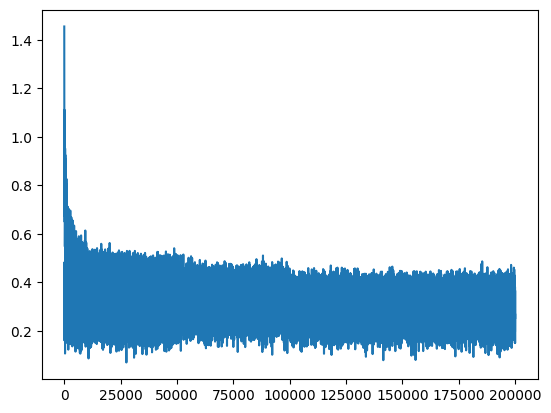

In [328]:
plt.plot(stepi, lossi)

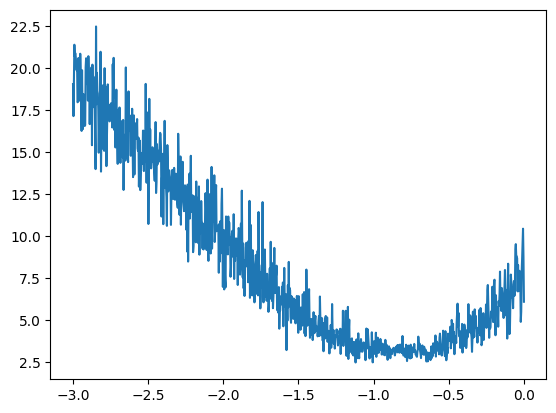

In [112]:
plt.plot(lri, lossi)

In [329]:
# finding the loss of the entire model and not a single minibatch
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0141, grad_fn=<NllLossBackward0>)

In [330]:
# finding the loss of the entire model and not a single minibatch
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3578, grad_fn=<NllLossBackward0>)

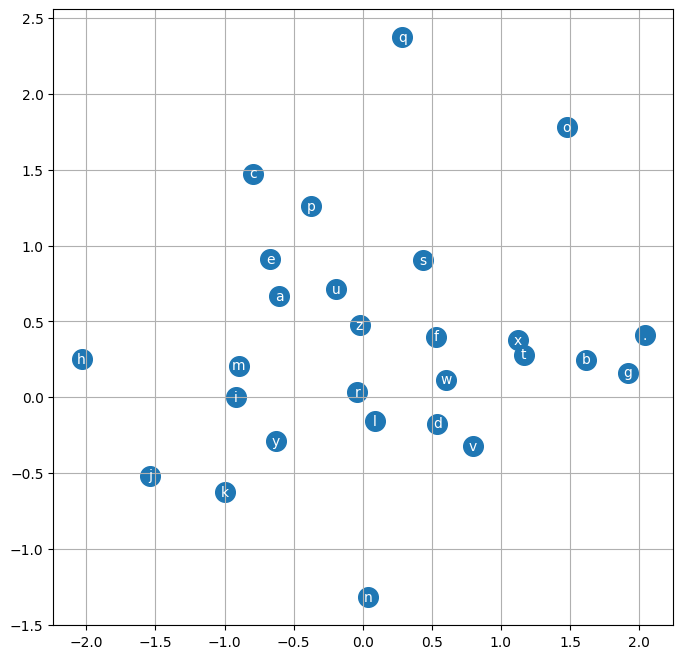

In [331]:
# visualizing the embeddings for size 2 
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [51]:
logits.max(1)

torch.return_types.max(
values=tensor([13.4206, 17.9792, 20.6837, 20.7368, 16.8675, 13.4206, 16.1245, 14.2801,
        16.0223, 18.5128, 16.0852, 21.0638, 13.4206, 17.2706, 17.2775, 20.2138,
        13.4206, 16.7157, 15.2712, 17.2145, 18.7032, 16.1175, 11.0066, 10.8034,
        15.5953, 13.4206, 16.2992, 17.0979, 12.8311, 16.2992, 19.2378, 16.2031],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [52]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [ ]:
# training split, dev/validation split, test split
# 80%, 10%, 10%


In [343]:
# sample from the modle

g = torch.Generator().manual_seed(2145483647 + 10)

for _ in range(20):
                                  
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1.block_size,d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

hatneya.
yari.
kny.
jensleanessly.
sydielle.
den.
mayley.
arisbettemon.
kaula.
ayaia.
nathesto.
ika.
reendie.
neylanes.
salexia.
gine.
adiya.
fabir.
luki.
brendy.
